# Explainable Skin Lesion Classifier - train on free GPU
**Runtime -> Change runtime type -> T4 GPU** before running.

In [1]:
# 1. Get the code (change URL if your repo name differs)
!git clone https://github.com/Afnan-Tahib/skin-lesion-gradcam.git
%cd skin-lesion-gradcam
!pip install -q -r requirements.txt

Cloning into 'skin-lesion-gradcam'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 16.74 KiB | 8.37 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/skin-lesion-gradcam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 90.6 MB/s eta 0:00:00


## 2. Download HAM10000
Get `kaggle.json` from Kaggle -> Settings -> API -> Create New Token, then upload it below.
(On a Kaggle notebook instead: attach the dataset and set `DATA_DIR='/kaggle/input/skin-cancer-mnist-ham10000'`, skip this cell.)

In [2]:
from google.colab import files
files.upload()   # choose kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p data/ --unzip -q
!ls data | head

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
ham10000_images_part_1
HAM10000_images_part_1
ham10000_images_part_2
HAM10000_images_part_2
HAM10000_metadata.csv
hmnist_28_28_L.csv
hmnist_28_28_RGB.csv
hmnist_8_8_L.csv
hmnist_8_8_RGB.csv


In [3]:
DATA_DIR = 'data'   # the code finds metadata + images recursively

## 3. Train (about 20-30 min on T4)

In [4]:
!python -m src.train --data-dir $DATA_DIR --epochs 12 --batch-size 32

Device: cuda
train=7002  val=1519  test=1494
train class counts: {'nv': 4718, 'mel': 770, 'bkl': 741, 'bcc': 381, 'akiec': 207, 'vasc': 96, 'df': 89}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 189MB/s]
Epoch 01/12 | train loss 1.288 acc 0.592 | val loss 0.943 acc 0.670 macroF1 0.518 | 71s  <- saved best
Epoch 02/12 | train loss 0.819 acc 0.683 | val loss 0.740 acc 0.721 macroF1 0.591 | 63s  <- saved best
Epoch 03/12 | train loss 0.669 acc 0.721 | val loss 0.698 acc 0.741 macroF1 0.598 | 64s  <- saved best
Epoch 04/12 | train loss 0.566 acc 0.751 | val loss 0.684 acc 0.739 macroF1 0.593 | 63s
Epoch 05/12 | train loss 0.483 acc 0.764 | val loss 0.645 acc 0.783 macroF1 0.666 | 65s  <- saved best
Epoch 06/12 | train loss 0.431 acc 0.792 | val loss 0.663 acc 0.766 macroF1 0.659 | 63s
Epoch 07/12 | train loss 0.372 acc 0.817 | val loss 0.6

## 4. Evaluate on held-out test set

In [5]:
!python -m src.evaluate --data-dir $DATA_DIR

              precision    recall  f1-score   support

       akiec      0.708     0.540     0.613        63
         bcc      0.662     0.779     0.716        68
         bkl      0.625     0.691     0.656       152
          df      0.300     0.429     0.353         7
         mel      0.444     0.706     0.545       187
          nv      0.949     0.826     0.884       996
        vasc      0.833     0.952     0.889        21

    accuracy                          0.783      1494
   macro avg      0.646     0.703     0.665      1494
weighted avg      0.825     0.783     0.797      1494

{
  "test_images": 1494,
  "accuracy": 0.7831325301204819,
  "macro_f1": 0.6651263774292333,
  "weighted_f1": 0.7966343171028066,
  "melanoma_recall": 0.7058823529411765,
  "melanoma_precision": 0.4444444444444444
}


## 5. Grad-CAM figures

In [6]:
!python -m src.gradcam --data-dir $DATA_DIR

saved results/gradcam_correct.png
saved results/gradcam_wrong.png


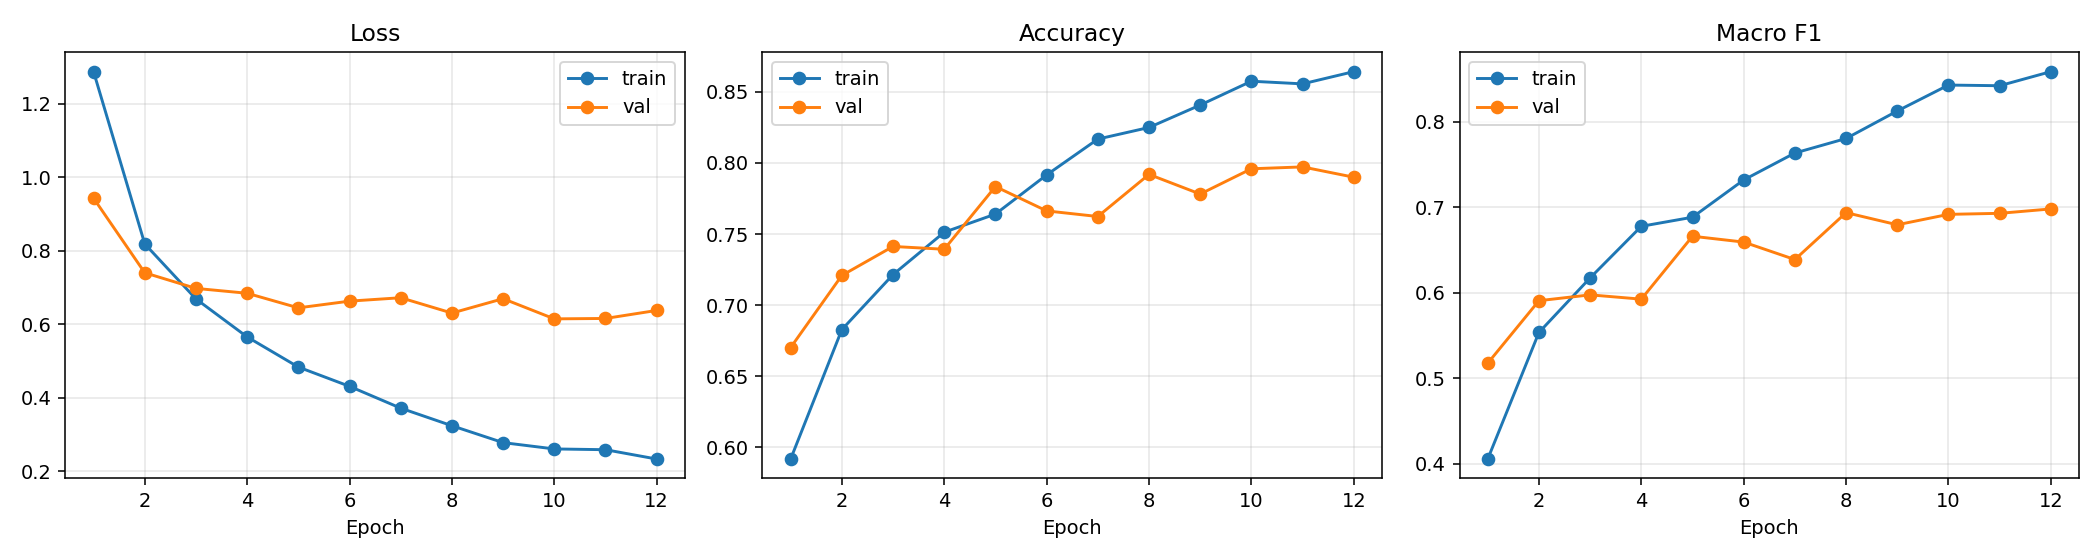

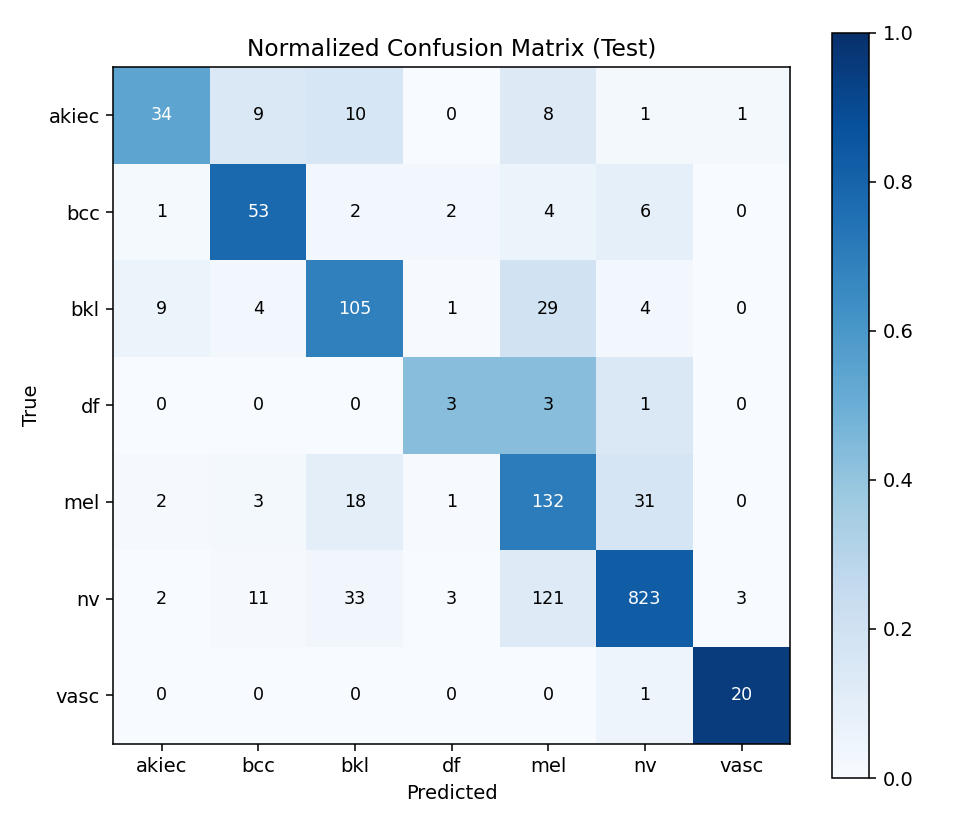

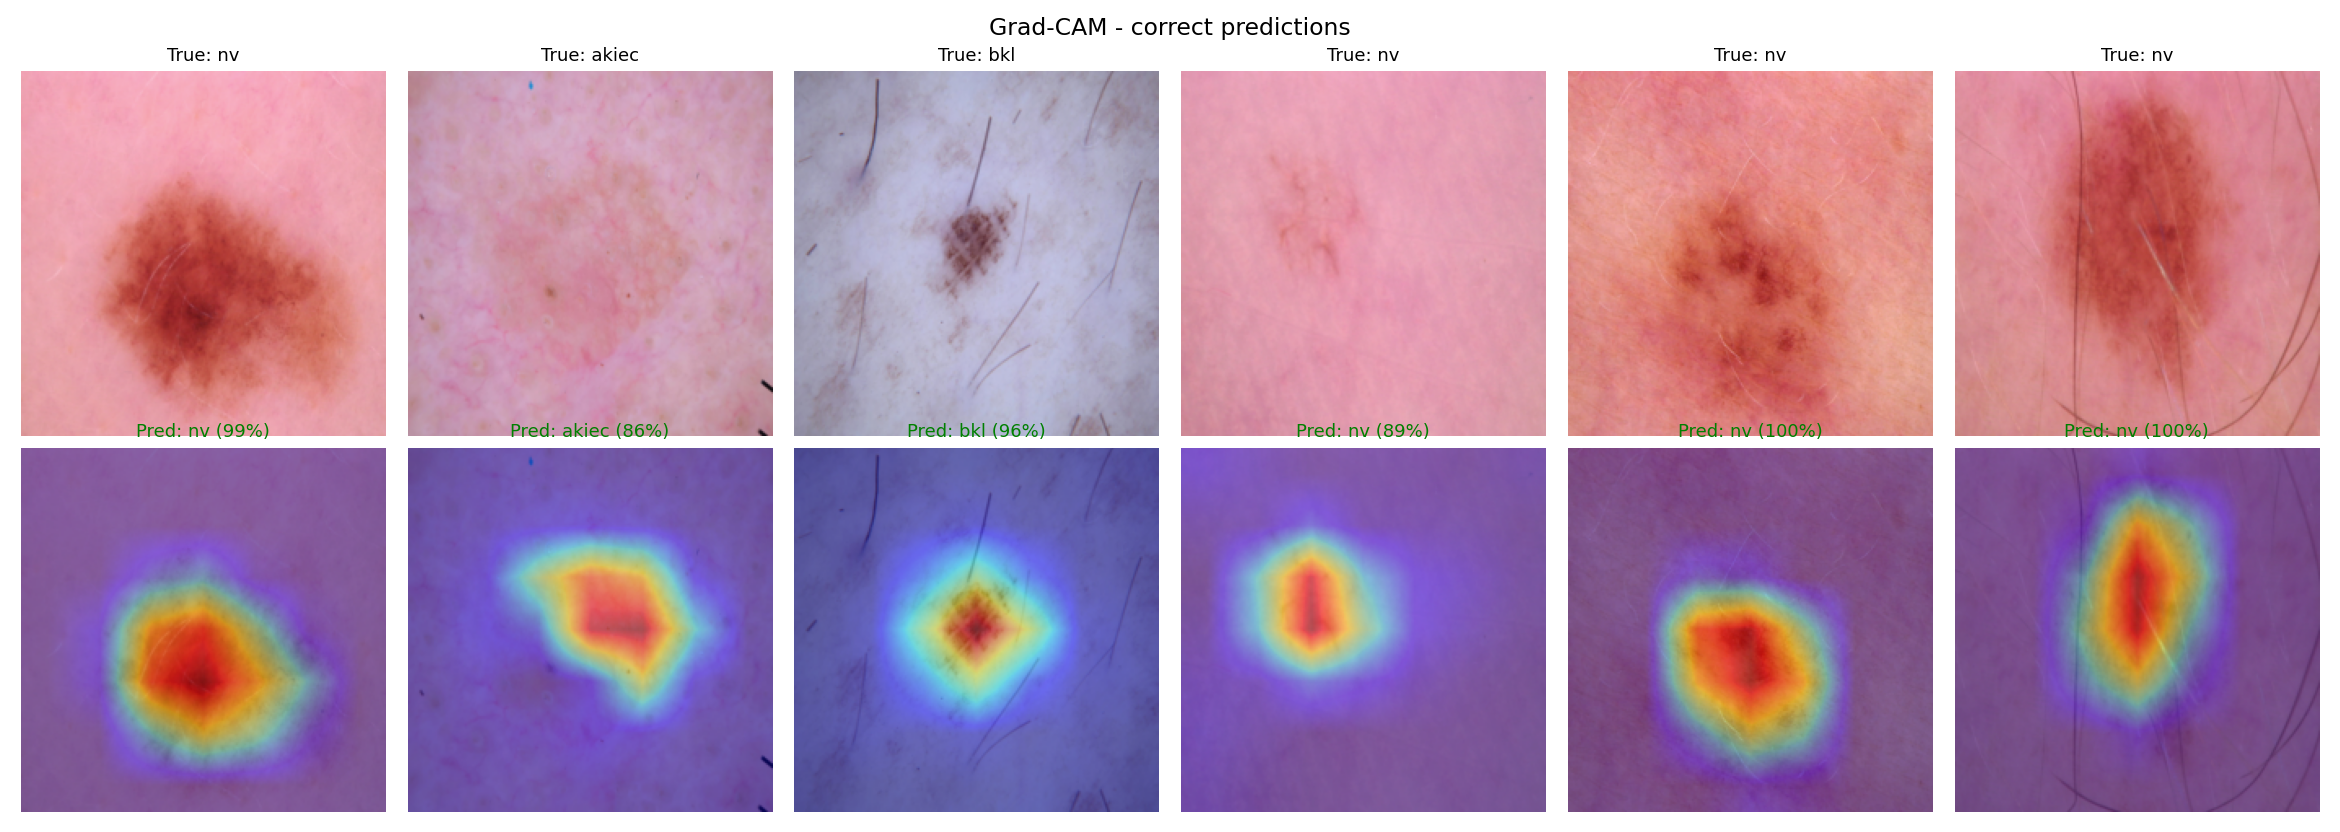

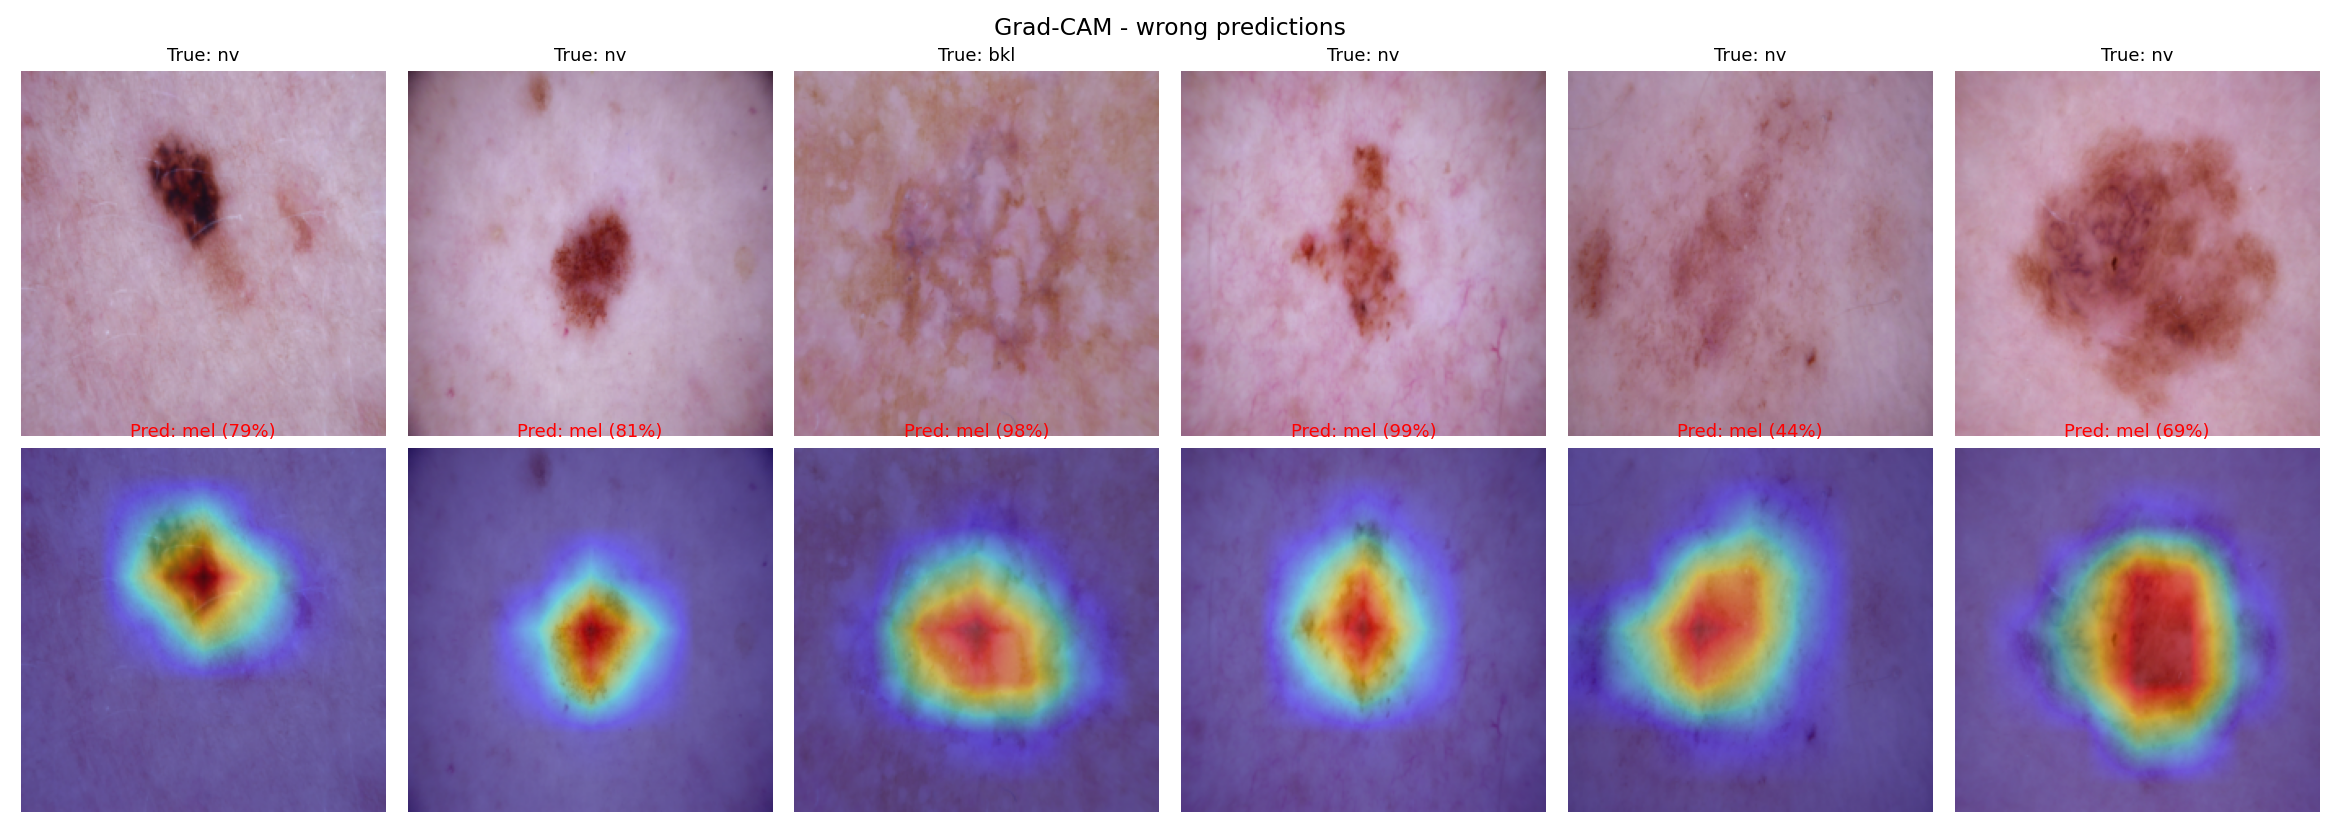

In [7]:
from IPython.display import Image, display
for f in ['training_curves','confusion_matrix','gradcam_correct','gradcam_wrong']:
    display(Image(f'results/{f}.png'))

## 6. Download everything, then commit to GitHub

In [8]:
!zip -rq outputs.zip models results
from google.colab import files
files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>